In [64]:
import numpy as np
import matplotlib.pyplot as plt
import time

## predefined helper functions

In [65]:
def generate_random_state(num_cabinets,num_chemicals):
    return np.random.randint(low=0,high=num_cabinets,size=num_chemicals)
    
def evaluate_conflicts(state,dict_constraints,scaler=True):
    con_mat = np.zeros((len(state),len(state)))
    for key,value in dict_constraints.items():
        con_mat[key,list(np.array(value))] = 1

    ch_mat = np.zeros((len(state),len(state)))
    for c in range(len(state)):
        occ = np.where(np.array(state)==state[c])[0]
        ch_mat[occ,[c]] = 1
        
        conflicts = con_mat*ch_mat
    if(scaler):    
        return np.sum(conflicts)
    else: 
        return conflicts

def has_conflict(conflicts,action):
    #action (m,n): material m in slot n
    return action[0] in conflicts[action[1]]

## Read constraints

In [66]:
f = open('Dataset.txt', "r")
lines = f.readlines()
f.close()
lines = [l.strip() for l in lines]
data = []
for l in lines:
    temp = [int(l) for l in l.split(',')]
    data.append(temp)

dict_constraints = {}

for d in data:
    dict_constraints[d[0]-1] = [v - 1 for v in d[1:]]


## initial configuration

In [67]:
num_chemicals = 200
num_cabinets = 50
rounds = 500

In [68]:
#sample state
generate_random_state(5,10)
#index: chemical - value: cabinet

array([3, 3, 0, 3, 3, 3, 3, 1, 2, 4])

In [69]:
def chemichals_per_cabinet(state):
    chemicals_per_cab={}
    for i in range(len(state)):
        if(state[i] in chemicals_per_cab):
            chemicals_per_cab[state[i]].append(i)
        else:
            chemicals_per_cab[state[i]]=[]
            chemicals_per_cab[state[i]].append(i)
    return chemicals_per_cab

## simulated annealing


In [70]:
def mutate(state,num_cabinets):
    num_chemicals = len(state)
    i = np.random.randint(0, num_chemicals )
    state[i] = np.random.randint(0, num_cabinets )
    return state

In [71]:
def run_sa(dict_constraints,tempreture=10000,decay=0.95,num_cabinets=20,rounds=500,num_chemicals=200):
    
    state_c = generate_random_state(num_cabinets,num_chemicals) #stats_c : current state
    conflicts_log = []
    
    for i in range(rounds):
        conflicts_c = evaluate_conflicts( state_c , dict_constraints )
        state_n = mutate(state_c.copy(),num_cabinets) # state_n: candidate next state 
        conflicts_n = evaluate_conflicts(state_n,dict_constraints) # number of conflicts of candidate next state
        delta_e = conflicts_n  -  conflicts_c # next state conflicts - current state conflicts
        acceptance_probability = np.exp(-delta_e/tempreture ) 
        acceptance_probability = min(acceptance_probability,1) # probabilities cant be bigger than one
        if( acceptance_probability>=np.random.rand() ): # if acceptance probablity is >= a random number between 0 and 1. remember that we want to make it STOCHASTIC. u can use np.random.rand()
            state_c = state_n
            conflicts_log.append(conflicts_n)
            if( conflicts_n==0 ): # if conflicts_n is zero, we have found an answer
                break
        else:
            conflicts_log.append(conflicts_c)
        
        tempreture *= decay  # decrease temp with decay rate
        
    return conflicts_log,state_c

C:\Users\Taniya\AppData\Local\Temp\ipykernel_1360\3582368544.py:11: RuntimeWarning: overflow encountered in exp
  acceptance_probability = np.exp(-delta_e/tempreture )


Elapsed 19665391.200 micro secs.
number of conflicts: 38.0
number of cabinets: 50

39:0	48	
6:1	56	82	150	185	
3:2	21	24	75	86	181	
10:3	5	14	125	195	
45:4	152	
30:6	83	104	
27:7	32	177	
38:8	33	80	87	98	123	146	
1:9	34	67	88	114	193	
25:10	30	31	37	102	119	160	
7:11	41	73	105	149	192	
0:12	26	27	184	
12:13	171	
17:15	59	71	74	81	132	182	
35:16	65	106	
14:17	61	155	186	
20:18	44	164	170	
40:19	47	52	179	
13:20	133	173	178	
49:22	77	112	144	158	189	
32:23	118	
9:25	29	99	172	
36:28	45	109	115	191	
24:35	128	180	
33:36	126	
28:38	46	85	107	130	
19:39	42	62	92	139	157	176	
8:40	90	161	162	
29:43	70	120	
37:49	50	93	135	151	
23:51	116	
46:53	55	84	
44:54	64	111	117	141	
21:57	143	147	
31:58	97	136	165	174	
42:60	113	121	127	129	166	175	194	
48:63	89	122	145	169	
34:66	78	103	159	167	199	
11:68	110	198	
15:69	91	
16:72	138	
2:76	79	96	134	137	
26:94	108	154	
22:95	140	190	
43:100	148	153	163	
5:101	168	183	
41:124	
18:131	142	156	
47:187	196	
4:188	197	

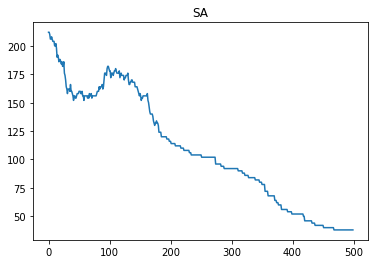

In [87]:
start = time.perf_counter()
conflicts_log_sa,state_sa = run_sa(num_chemicals=num_chemicals,dict_constraints=dict_constraints,rounds=rounds,num_cabinets=num_cabinets)
end = time.perf_counter()
ms = (end-start) * 10**6
print(f"Elapsed {ms:.03f} micro secs.")
print(f"number of conflicts: {conflicts_log_sa[-1]}")
print(f"number of cabinets: {len(np.unique(state_sa))}")
dict_of_cabinets=chemichals_per_cabinet(state_sa)
for key in dict_of_cabinets.keys():
    print(f"\n{key}:",end='')
    for value in dict_of_cabinets[key]:
        print(value, end='\t')

plt.title('SA')
plt.plot(conflicts_log_sa,label='SA')
plt.show()

## Genectic Algorithm

In [80]:
def cross_over(state1,state2):
    cursor = np.random.randint(len(state1)) # generate a random index between 0 and len(state)
    state3 = np.zeros_like(state1)
    # take one side of cursor from each state to make a new state
    if(np.random.rand()<0.5):
        # take first side from state 1 and second side of cursor from state 2
        state3[: cursor ] = state1[: cursor ]
        state3[ cursor :] = state2[ cursor :]
    else:
        # take first side from state 2 and second side of cursor from state 1
        state3[: cursor ] = state2[: cursor ]
        state3[ cursor :] = state1[ cursor :]
    return state3

In [81]:
# In our implementation of GA chromosome, state and character "c" are all the same. notice that these name can be used interchangably

def run_ga(dict_constraints,cpp=8,num_cabinets=20,rounds=500,num_chemicals=200): #cpp: chromosome per population
    population = []

    for i in range(cpp):
        population.append(generate_random_state( num_cabinets , num_chemicals ))
    
    conflicts_log = []
    for i in range(rounds):
        conflicts = []
        for chromosome in population: # chromosome/state in the population
            conflicts.append(evaluate_conflicts( chromosome , dict_constraints ))
        
        min_conflict = np.min(conflicts)
        conflicts_log.append(min_conflict)
        if( min_conflict==0 ): # the minimum conflicts is 0 so having 0 conflicts means that we have found an answer
            break
        
        # assign a probability to each chromosome with respect to its number of conflicts
        # write these probabilities to an array and call it selection_probabilities
        # Notic: chromosomes with more conflicts should have less selection probability and vice verca
        selection_probabilities=[]
        for conflict in conflicts:
            selection_probabilities.append((0.3**conflict)/np.sum(np.power(0.3,conflicts)))

        new_population = []
        for i in range(cpp):
            # choose 2 random samples (chromosomes) from population. better samples should be chosen with higher probabilty
            c1_index,c2_index = np.random.choice(np.arange(cpp),2,True, selection_probabilities)
            c3 = cross_over( population[c1_index] , population[c2_index] )
            c3 = mutate( c3 ,num_cabinets )
            new_population.append(c3)
        population = new_population

    return conflicts_log,population[np.argmin(conflicts)] # the chromosome with least conflicts. u can use np.argmin
    # conflicts_log is just a report of how well the algorithms worked in each round.

Elapsed 29397006.900 micro secs.
number of conflicts: 0.0
number of cabinets: 50

29:0	30	52	67	82	168	
6:1	80	145	166	
3:2	53	154	
21:3	108	130	
5:4	21	37	70	114	
2:5	27	75	88	92	103	
42:6	60	65	123	164	181	
24:7	22	100	198	
15:8	11	167	
20:9	16	71	165	
46:10	39	55	102	104	150	185	
25:12	117	134	162	
43:13	113	
44:14	28	179	
37:15	74	188	
12:17	26	48	194	
14:18	73	85	
28:19	149	186	
9:20	125	131	
23:23	112	126	127	129	138	173	175	
45:24	35	58	97	121	
48:25	42	91	101	159	189	
30:29	98	174	187	
16:31	33	158	180	
27:32	118	132	136	196	
17:34	59	93	95	96	106	142	153	
34:36	135	182	191	
13:38	63	119	
8:40	47	161	163	176	184	
7:41	99	122	171	
0:43	49	56	89	110	152	
11:44	68	105	
1:45	64	78	84	
35:46	51	94	147	
22:50	62	140	197	
36:54	146	
47:57	66	116	199	
49:61	183	
41:69	115	151	
26:72	139	148	190	
32:76	120	124	128	160	178	
18:77	81	
39:79	156	157	
19:83	86	143	155	177	193	
31:87	
10:90	107	133	170	192	
38:109	
33:111	144	
40:137	141	
4:169	172	195	

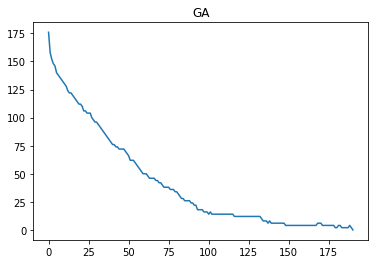

In [88]:
start = time.perf_counter()
conflicts_log_ga,state_ga = run_ga(num_chemicals=num_chemicals,dict_constraints=dict_constraints,rounds=rounds,num_cabinets=num_cabinets)
end = time.perf_counter()
ms = (end-start) * 10**6
print(f"Elapsed {ms:.03f} micro secs.")
print(f"number of conflicts: {conflicts_log_ga[-1]}")
print(f"number of cabinets: {len(np.unique(state_ga))}")
dict_of_cabinets=chemichals_per_cabinet(state_ga)
for key in dict_of_cabinets.keys():
    print(f"\n{key}:",end='')
    for value in dict_of_cabinets[key]:
        print(value, end='\t')

plt.title('GA')
plt.plot(conflicts_log_ga,label='GA')
plt.show()

## Iterative Minimum Conflict

In [51]:
def next_greedy_state(state,num_cabinets,dict_constraints):
    
    conflicts_matrix = evaluate_conflicts(state=state,dict_constraints=dict_constraints,scaler=False)
    conflicts_per_chemical = np.sum(conflicts_matrix,axis=0)
    # conflicts_per_chemical is an array with shape (num_chemicals,1) that shows how many conflicts are caused by each chemical
    # you can print it to check it yourself.
    # choose the chemical that has caused biggest number of conflicts
    max_conflict_chemical = np.argmax( conflicts_per_chemical )
    state[ max_conflict_chemical ] = np.random.randint(0, num_cabinets) # change its cabinet to a random cabinet

    return state
            
def run_imc(dict_constraints,num_cabinets=20,num_chemicals=200,rounds=200):
    conflicts_log = []
    state = generate_random_state(num_cabinets,num_chemicals)
    for i in range( rounds ):
        # find a chemical with biggest number of conflicts and move to a another random cabinet
        state = next_greedy_state(  state  , num_cabinets , dict_constraints )
        conflicts = evaluate_conflicts( state , dict_constraints )
        conflicts_log.append( conflicts )
        if  (conflicts==0) : # conflicts is zero, we have found an answer
            break
    return conflicts_log,state
        

Elapsed 4939880.100 micro secs.
number of conflicts: 42.0
number of cabinets: 50

17:0	133	137	148	153	
7:1	30	103	193	
33:2	20	61	143	154	162	186	
45:3	24	82	123	
20:4	37	45	65	127	164	
29:5	71	126	166	
38:6	35	50	
18:7	26	142	167	190	
8:8	33	107	
32:9	11	16	17	
42:10	98	114	119	136	
21:12	63	188	
34:13	
25:14	18	83	122	199	
9:15	19	110	194	
30:21	53	101	161	
16:22	66	112	183	
31:23	49	70	79	
19:25	31	40	179	184	
24:27	84	170	
3:28	52	90	168	
28:29	67	106	111	
40:32	41	58	74	
2:34	120	174	192	
39:36	88	197	198	
0:38	55	95	116	177	
41:39	57	135	
15:42	81	89	93	140	163	187	
12:43	44	100	108	113	131	178	
10:46	54	76	117	129	
23:47	109	181	182	196	
6:48	
47:51	96	
48:56	59	175	
49:60	64	134	138	160	
44:62	69	
13:68	85	97	118	156	158	
43:72	94	146	189	
11:73	86	141	165	176	180	195	
5:75	102	124	139	151	
36:77	128	152	
1:78	121	130	
35:80	125	173	
37:87	144	191	
22:91	92	104	150	172	
14:99	132	171	
4:105	157	
26:115	147	149	
46:145	169	
27:155	159	185	

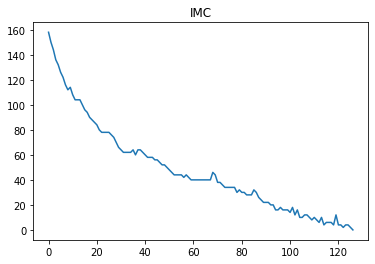

In [85]:
start = time.perf_counter()
conflicts_log_imc,state_imc = run_imc(num_chemicals=num_chemicals,dict_constraints=dict_constraints,rounds=rounds,num_cabinets=num_cabinets)
end = time.perf_counter()
ms = (end-start) * 10**6
print(f"Elapsed {ms:.03f} micro secs.")
print(f"number of conflicts: {conflicts_log_sa[-1]}")
print(f"number of cabinets: {len(np.unique(state_ga))}")
dict_of_cabinets=chemichals_per_cabinet(state_sa)
for key in dict_of_cabinets.keys():
    print(f"\n{key}:",end='')
    for value in dict_of_cabinets[key]:
        print(value, end='\t')
plt.title('IMC')
plt.plot(conflicts_log_imc,label='IMC')
plt.show()

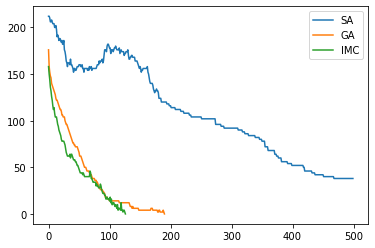

In [89]:
plt.plot(conflicts_log_sa,label='SA')
plt.plot(conflicts_log_ga,label='GA')
plt.plot(conflicts_log_imc,label='IMC')
plt.legend()
plt.show()

## Backtracking

In [15]:
class Stack:
    "A cabinet with a last-in-first-out (LIFO) queuing policy."
    def __init__(self):
        self.list = []

    def push(self,item):
        "Push 'item' onto the stack"
        self.list.append(item)

    def pop(self):
        "Pop the most recently pushed item from the stack"
        return self.list.pop()

    def is_empty(self):
        "Returns true if the stack is empty"
        return len(self.list) == 0


class CSP_problem:
    def __init__(self,num_cabinets,num_chemicals,dict_constraints):
        self.num_cabinets = num_cabinets
        self.num_chemicals = num_chemicals
        self.dict_constraints = dict_constraints
        
    def get_successors(self,state):
        successors = []
        actions = np.arange(self.num_cabinets)
        unassigned_chemical_index = np.where(state==-1)[0][0]
        
        for action in actions:
            cost = 0
            next_state = state.copy()
            next_state[ unassigned_chemical_index ] =  action 
            if(np.sum(next_state==action)==1): # used an empty cabinet
                cost = 1
                
            # evaluate number of conflicts on this specific cabinet
            conflicts = self.evaluate_conflicts(next_state,unassigned_chemical_index,self.dict_constraints) 
            if( conflicts==0 ):
                successors.append(( next_state , action , cost ))

        return successors
    
    
    def evaluate_conflicts(self,state,index,dict_constraints):
        conflicts = 0
        shared_set = set(np.where(state==state[index])[0])
        constraint_set = set(dict_constraints[index])
        conflicts += len(shared_set.intersection(constraint_set))

        return conflicts
            
            
    
#    def is_goal_state(self,state):
    def get_start_state(self):
        # start state is array: [-1,-1,-1 ..., -1] with shape(num_chemicals)
        # This means all of the chemicals are assigned to cabinet with index -1
        # which means we have not put them in any cabinet yet
        state = -np.ones(self.num_chemicals)
        return state
    
    def is_goal_state(self,state):
        return np.sum(state==-1)==0

def generic_search(problem, fringe, add_to_fringe_fn):
    start = (problem.get_start_state(), 0)  # (node, cost)
    add_to_fringe_fn(fringe, start, 0)
    visited_nodes_count = 0
    while not fringe.is_empty():
        (node,cost) = fringe.pop()
        visited_nodes_count +=1
        
        if problem.is_goal_state(node):
            return node,visited_nodes_count

        for child_node, child_action, child_cost in problem.get_successors(node):
            new_cost = cost + child_cost
            new_state = (child_node, new_cost)
            add_to_fringe_fn(fringe, new_state, new_cost)

            
def dfs(problem):
    fringe = Stack()
    def add_to_fringe_fn(fringe, state, cost):
        fringe.push(state)

    return generic_search(problem, fringe, add_to_fringe_fn)

def run_dfs(num_chemicals,num_cabinets,dict_constraints):
    problem = CSP_problem(num_cabinets,num_chemicals,dict_constraints)
    solution,visited_nodes_count = dfs(problem)
    return solution,visited_nodes_count

In [16]:
num_cabinets = 25

solution,visited_nodes_count = run_dfs(num_chemicals=num_chemicals,num_cabinets=num_cabinets,dict_constraints=dict_constraints)
conflicts = evaluate_conflicts(solution,dict_constraints)
if(conflicts == 0):

    print(f"There is a solution for putting {num_chemicals} chemicals in {num_cabinets} cabinets, while keeping the constraints satisfied")
else:
    print(f"there is NO solution for puting {num_chemicals} chemicals in {num_cabinets} cabinets,  while keeping the constraints satisfied")         

There is a solution for putting 200 chemicals in 25 cabinets, while keeping the constraints satisfied


# 1
chromosomes in GA algorithm are arrays of size num_chemicals and they are randomly initialized at first. but then in each step we use cross-over and mutation to change them.
states in SA algorithm are arrays of size num_chemicals and they are randomly initialized at first. but then in each step we use mutation to change them. then we calculate old states conflicts vs new states conflicts and update it if needed.
# 2
in both algoritms our cost is the number of conflicts and we want to find the state with min conflicts.
in SA algorithm, we try to find it using the Boltzmann constant e^(-delta_e/tempreture) as a probability for accepting the next state. so if the next state has more conflicts we accept it with this probability.
in GA algorithm, we try to find the chromosome with min conflicts in each generation of population. for doing that we need to choose 2 chromosomes with some probability. I have used the function below to choose the chromosome (with lower conflicts) with a higher probability:
c= constant between 0 and 1
((c)^(conflict))/(sum of (c^(each entry of conflicts list)) )
with this probability function each chromosome with less conflicts has a higher probaility to be chosen as a part of the cross-over.(NOTE: I have chosen 0.3 as the constant between 0 and 1 but it could be anything.)

# 3
in this algorithm we use mutation(which is: changing the cabinet of one randomly chosen chemical) to generate a new state. we call it next_state and we calculate it's conflicts (we call it conflict_n) and if conflict_n < conflict_c (conflicts of current state) then we move to next state. otherwise we stay in the current state and use mutation again...
# 4
backtracking algorithm guarantees finding the answer with zero conflicts(if it exists) and as we can see it can find the answer for 25 cabinets.(but if we try running it for less cabinets for ex. 20 cabinets, it will still find the suitable answer.)

min conflict algorithm finds the answer very fast (mostly faster than any other algorithm). as we know this algorithm starts with an initial state and moves to the next state (next state: the state that has changed the old state in a way that the chemical with max conflict will be move to a random cabinet.)

GA algorithm finds the answer very fast as well. this algorithm will use different chromosomes(with random initialization) in a population and cross-over them with a appropriate probability. the next generation of chromosomes [mostly] will be the one which is more suitable (with less conflicts). we have to run this algorithm several times to reach to a state with 0 conflicts and also it doesn't guarantee finding an answer.

SA algorithm needs more rounds to find the answer, as we can see (mostly) it cannot find the answer with 0 conflicts in 500 rounds. this algorithm uses random initialization for the starting state, and then accepts moving to the next state with Boltzmann constant probability. so if the next state is a better answer, the current state is replaced with the next one. but if it isn't it will be replaced with the probability mentioned above. (doing this procedure helps us to fing the global optimal answer). as we can see in the plot, this algorithm has been exploring more at first ( because tempreture was bigger) and then as we carry on we can see that it only moves to the states which are better than the current one.we have to run this algorithm several times to reach to a state with 0 conflicts and also it doesn't guarantee finding an answer. 

# 5
for SA algorithm:
- we have used decay=0.95 which means we are decreasing tempreture very slowly.


for GA algorithm:
- cpp=8
- the constant used for calculatin selection_probabilities is 0.3(a number between 0 and 1)



for both algorithms:
- starting tempreture is 10000
- rounds=500
- num_cabinets=20
- num_chemichals=200
# 6
in backtracking we initialize the start state with -1. that means we are in a empty state not a complete state, so we cannot count the number of conflicts as we haven't assigned anything to chemicals. as we move on, we assign values to variables and still we cannot count the number of conflicts as there are some unassigned values.
# 7
backtracking algorithm is a suitable one for finding the min number of cabinets because the tree that it has to traverse gets smaller than what it is and also it guarantees a answer so we are not going to be overwhelmed if we don't find the answer with specific number of rounds running the algorithm. this is the problem for finding the min answer for GA and SA and min conflict algorithms, because as we are decreasing he number of cabinets,the feasible area gets smaller relative to the state space. and therefore, finding the answer gets harder. (because we are finding the answer in using random cabinets)


